# Cell Crawling BTP — Version 2

## Protrusion and Steady Crawling at a Wall, with Exactly Conserved Volume

### Goal of Version 2

Version 1 put a round cell in free space with a uniform actin polarization and
watched it translate. It could not form a protrusion, and it lost about 4.5% of
its area over the run.

Version 2 targets Fig. 1a of Tjhung *et al.*, *Nat. Commun.* **6**, 5420 (2015):
a cell sitting on a solid substrate that **extends a thin protrusion at its
leading edge and crawls steadily forward**, while its **volume stays exactly
constant**.

Three changes make that possible.

**1. Side-view geometry.** Version 1 was a top view in the $x$–$y$ plane. The
protrusion in Fig. 1a is a *side* view: the axes are $y$ (along the substrate)
and $z$ (height above it), with a wall at $z=0$. We switch to that slice.

**2. A treadmilling rate that decays away from the wall.**

$$
w(z) \;=\; w_0\,\Big[\tfrac{1}{2}\big(1-\tanh\tfrac{z-\lambda}{w_\tau}\big)\Big]
$$

This is the single most important ingredient. Material within a thickness
$\lambda$ of the substrate is pushed forward hard; material above it is not.
The near-wall layer runs out ahead of the cell body and surface tension pulls
it back — the steady state of that competition **is** the protrusion, and
$\lambda$ sets its thickness. With the spatially uniform $w_0$ of Version 1
there is no such gradient and the cell can only translate rigidly.

**3. Exact volume conservation.** The advection is written in conservative flux
form and the relaxation carries a Lagrange multiplier, so $\int\phi\,dA$ is
constant to machine precision (typically $10^{-16}$ relative). Details in
Section 6.

## Relation to the paper, and what is deliberately left out

The paper's concentration and polarization equations are

$$
\frac{\partial\phi}{\partial t}+\nabla\cdot\big[\phi(\mathbf v+w_0\mathbf P)\big]
=\nabla\cdot\Big(M\nabla\frac{\delta F}{\delta\phi}\Big),
$$

$$
\frac{\partial\mathbf P}{\partial t}+\big[(\mathbf v+w_0\mathbf P)\cdot\nabla\big]\mathbf P
=-\mathbf\Omega\cdot\mathbf P+\chi\mathbf D\cdot\mathbf P-\frac{1}{\Gamma}\frac{\delta F}{\delta\mathbf P},
$$

together with Navier–Stokes for $\mathbf v$.

**We do not solve Navier–Stokes.** Instead of dropping $\mathbf v$ entirely (which
is what Version 1 did, and which turns out to fail here — see below), we replace
it with the cheapest closure that keeps the essential effect of viscosity.

### Why $\mathbf v = 0$ is not good enough any more

If only the near-wall layer is advected and nothing couples it to the rest of
the cell, the cell body simply lags behind and the whole droplet shears into a
flat slab. There is no protrusion, because there is no cell body left for the
protrusion to protrude *from*. In a real cell, viscosity transmits the
near-wall driving to the interior over a finite distance.

### The closure we use instead

In the thin-film (lubrication) limit of the Stokes equation for a layer on a
substrate with friction $\xi$ and shear viscosity $\eta$, vertical momentum
diffusion dominates and the steady velocity obeys a **screened-Poisson**
(Brinkman) equation

$$
\Big(1-\ell_v^{2}\frac{\partial^{2}}{\partial z^{2}}\Big)\,\mathbf u \;=\; w(z)\,\mathbf P,
\qquad \ell_v=\sqrt{\eta/\xi}.
$$

$\ell_v$ is the **viscous screening length**: the distance over which the
substrate driving is communicated into the cell body. It is a single new
parameter, it is physically interpretable (large $\ell_v$ = weak adhesion, the
cell moves as a rigid plug; small $\ell_v$ = strong adhesion, only the bottom
layer slides), and it costs one **tridiagonal solve per time step** — a linear
solve, not a Navier–Stokes solver. Because the operator is applied only in $z$
with Neumann conditions, it preserves $\int u\,dz$ exactly, so it redistributes
the driving without inventing or destroying any.

### Still not included

Active (contractile) stress $\zeta$, flow alignment $\chi\mathbf D$ and vorticity
$\mathbf\Omega$, in-plane pressure and true incompressibility, the substrate slip
parameter $s$, spontaneous symmetry breaking of $\mathbf P$, and the third
dimension. Version 2 is a controlled step, not a full reproduction.

## Geometry and boundary conditions

The domain is a vertical slice: $y$ along the substrate, $z$ upward, wall at $z=0$.

| direction | field | condition | meaning |
|---|---|---|---|
| $y$ | all | periodic | cell crawls freely; we re-centre by integer shifts |
| $z=0$ | $\phi$ | $\partial_z\phi=0$ | neutral wetting, i.e. a 90° contact angle, so the cell sits on the wall |
| $z=0$ | $P_y$ | $\partial_z P_y=0$ | polarization free to lie **along** the wall |
| $z=0$ | $P_z$ | $P_z=0$ | polarization **anchored parallel** to the wall (the paper's wall condition) |
| $z=L_z$ | all | $\partial_z=0$ | far field |
| $z=0,L_z$ | flux | $\phi u_z=0$ | no material crosses the wall or escapes upward |

The two wall conditions on $\mathbf P$ are imposed with a **parity trick**: the
ghost cell below the wall is a mirror image, taken *even* for quantities that
should be free there ($\phi$, $P_y$) and *odd* for $P_z$, which forces $P_z$ to
vanish at the wall. One padding routine handles both.

Since $y$ is periodic, the cell would eventually wrap around. We keep it in
view by rolling the arrays by a whole number of grid cells whenever its centre
of mass drifts from the middle. An integer roll is exact — it conserves mass to
machine precision and introduces no interpolation error — and we accumulate the
shifts to recover the true trajectory.

# 1. Imports and parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

# ============================================================
# Cell Crawling BTP - Version 2
#
#   phi(y,z,t)   : cell phase field, on a wall at z = 0
#   P(y,z,t)     : actin polarization
#   w(z) P       : treadmilling drive, confined near the wall
#   u            : advecting velocity = viscously screened drive
#
#   Volume int(phi) is conserved to machine precision.
# ============================================================

# ---------------- grid ----------------
Ny, Nz = 256, 64
dy = dz = 0.5
Ly, Lz = Ny * dy, Nz * dz

# cell-centred coordinates: the wall sits at z = 0, half a cell below z[0]
y = (np.arange(Ny) + 0.5) * dy
z = (np.arange(Nz) + 0.5) * dz
Y, Z = np.meshgrid(y, z, indexing="ij")

# ---------------- cell ----------------
R0 = 22.0              # initial radius of the cap
eps = 1.5              # diffuse interface width
M_phi = 1.0            # phase-field relaxation rate (sets surface tension relaxation)

# ---------------- treadmilling ----------------
w0 = 2.0               # treadmilling rate
lam = 3.0              # thickness of the treadmilling layer at the wall
w_tau = 1.0            # sharpness of that layer's upper edge
lv = 4.0               # viscous screening length (small = strong adhesion)

# ---------------- polarization ----------------
a_pol = 1.0            # bulk polarization strength, sets |P| = 1 inside the cell
kappa = 1.0            # polarization elasticity (Frank constant)
Gamma = 1.0            # rotational viscosity
beta_anch = 0.0        # interface anchoring; 0 keeps Version 2 minimal

# ---------------- time ----------------
dt = 0.01
t_final = 400.0
sample_every = 200     # steps between diagnostic samples / re-centrings

print(f"domain {Ly:g} x {Lz:g},  grid {Ny} x {Nz},  dx = {dy:g}")
print(f"interface spans {np.sqrt(2)*eps/dy:.1f} cells,  treadmilling layer {lam/dz:.0f} cells")

domain 128 x 32,  grid 256 x 64,  dx = 0.5
interface spans 4.2 cells,  treadmilling layer 6 cells


# 2. Derivatives with a wall

In $y$ everything is periodic, so `np.roll` is enough. In $z$ we need ghost
cells outside the domain. `pad_z` builds them by mirroring, with a sign
`parity` that selects the boundary condition at the wall:

- `parity = +1` (even mirror) $\Rightarrow$ $\partial_z a = 0$ at the wall. Used for
  $\phi$ and $P_y$.
- `parity = -1` (odd mirror) $\Rightarrow$ $a = 0$ at the wall. Used for $P_z$, which
  is how the polarization gets anchored parallel to the substrate.

The top boundary is always an even mirror.

In [2]:
def pad_z(a, parity):
    """Add one ghost column below and above in z. parity = +1 mirrors (Neumann),
    parity = -1 anti-mirrors (value zero at the wall)."""
    out = np.empty((a.shape[0], a.shape[1] + 2))
    out[:, 1:-1] = a
    out[:, 0] = parity * a[:, 0]     # below the wall
    out[:, -1] = a[:, -1]            # above the top
    return out


def d_dy(a):
    return (np.roll(a, -1, axis=0) - np.roll(a, 1, axis=0)) / (2.0 * dy)


def d_dz(a, parity=1):
    ap = pad_z(a, parity)
    return (ap[:, 2:] - ap[:, :-2]) / (2.0 * dz)


def laplacian(a, parity=1):
    ap = pad_z(a, parity)
    return ((np.roll(a, -1, axis=0) + np.roll(a, 1, axis=0) - 2.0 * a) / dy**2
            + (ap[:, 2:] + ap[:, :-2] - 2.0 * a) / dz**2)

# 3. Conservative advection

Version 1 advected the cell field as $\mathbf u\cdot\nabla\phi$. That form does
not conserve $\int\phi$ once $\nabla\cdot\mathbf u\neq0$, and combined with a
`clip(0,1)` it quietly leaked mass.

Here we use the **flux form** of the paper's Eq. (8),

$$
\frac{\partial\phi}{\partial t}\Big|_{\text{advection}} = -\nabla\cdot(\phi\,\mathbf u),
$$

discretised on cell **faces**:

$$
F^{y}_{i+1/2,j}=\tfrac12(\phi_{i,j}+\phi_{i+1,j})\cdot\tfrac12(u^y_{i,j}+u^y_{i+1,j}).
$$

Whatever leaves one cell enters its neighbour, so the sum over the grid
telescopes and the total changes only through the domain boundary. In $y$ the
boundary is periodic, and in $z$ we set the wall and top face fluxes to exactly
zero. **Total mass is therefore conserved identically, by construction, not by
accuracy.**

In [3]:
def divergence_of_flux(phi, uy, uz):
    """Conservative discretisation of div(phi * u), evaluated on cell faces."""
    # --- y faces (periodic) ---
    phi_face = 0.5 * (phi + np.roll(phi, -1, axis=0))
    uy_face = 0.5 * (uy + np.roll(uy, -1, axis=0))
    Fy = phi_face * uy_face                                   # flux at i+1/2
    div = (Fy - np.roll(Fy, 1, axis=0)) / dy

    # --- z faces (wall and top are impermeable, so those fluxes stay zero) ---
    Fz = np.zeros((phi.shape[0], phi.shape[1] + 1))
    Fz[:, 1:-1] = (0.5 * (phi[:, :-1] + phi[:, 1:])
                   * 0.5 * (uz[:, :-1] + uz[:, 1:]))
    div += (Fz[:, 1:] - Fz[:, :-1]) / dz
    return div

# 4. Viscous screening: the stand-in for the flow field

We need to solve

$$
\Big(1-\ell_v^{2}\,\partial_z^{2}\Big)u \;=\; w(z)\,P
$$

for $u$ at every time step. Discretised in $z$ this is a **tridiagonal** system
in each column of the grid, identical for every column, so we factorise it once
with the Thomas algorithm and reuse the factors. Cost per step is $O(N_yN_z)$,
the same order as one Laplacian.

The wall condition follows the same parity convention as before: even mirror for
$u_y$, odd for $u_z$. With Neumann conditions the operator leaves $\int u\,dz$
unchanged, so the screening only *redistributes* the treadmilling drive in $z$ —
it spreads the near-wall push into the cell body without adding or removing any.

Limiting cases worth keeping in mind:

- $\ell_v\to0$: no coupling. Only the bottom layer moves and the cell shears into a slab.
- $\ell_v\gg$ cell height: the profile is flat. The cell translates as a rigid plug and no protrusion forms.
- intermediate: a fast near-wall layer above a slower body — the regime that produces a protrusion.

In [4]:
def make_screening_solver(l, parity):
    """Return a function applying (1 - l^2 d^2/dz^2)^-1 down each column of z.

    Tridiagonal, constant coefficients, so the Thomas factorisation is done once.
    parity = +1 : dz(u) = 0 at the wall.   parity = -1 : u = 0 at the wall.
    """
    if l <= 0:
        return lambda rhs: rhs

    r = l * l / dz**2
    lower = np.full(Nz, -r)
    diag = np.full(Nz, 1.0 + 2.0 * r)
    upper = np.full(Nz, -r)

    diag[0] = 1.0 + (1.0 if parity == 1 else 3.0) * r   # wall ghost folded in
    diag[-1] = 1.0 + r                                   # top ghost folded in
    lower[0] = 0.0
    upper[-1] = 0.0

    # forward sweep of the Thomas algorithm, done once
    c_star = np.empty(Nz)
    denom = np.empty(Nz)
    denom[0] = diag[0]
    c_star[0] = upper[0] / denom[0]
    for j in range(1, Nz):
        denom[j] = diag[j] - lower[j] * c_star[j - 1]
        c_star[j] = upper[j] / denom[j]

    def solve(rhs):
        x = np.empty_like(rhs)
        x[:, 0] = rhs[:, 0] / denom[0]
        for j in range(1, Nz):
            x[:, j] = (rhs[:, j] - lower[j] * x[:, j - 1]) / denom[j]
        for j in range(Nz - 2, -1, -1):
            x[:, j] -= c_star[j] * x[:, j + 1]
        return x

    return solve

# 5. Initial cell and treadmilling profile

The cell starts as a half-disc of radius $R_0$ resting on the wall,

$$
\phi=\tfrac12\Big(1-\tanh\frac{r-R_0}{\sqrt2\,\varepsilon}\Big),
\qquad r=\sqrt{(y-y_0)^2+z^2},
$$

which with the neutral-wetting wall condition is the equilibrium shape at a 90°
contact angle. The polarization starts at $\mathbf P=(\phi,0)$, i.e. pointing
along $+y$ inside the cell and vanishing outside.

The treadmilling profile is a smoothed step of height $w_0$ and thickness
$\lambda$:

$$
w(z)=w_0\cdot\tfrac12\Big(1-\tanh\frac{z-\lambda}{w_\tau}\Big).
$$

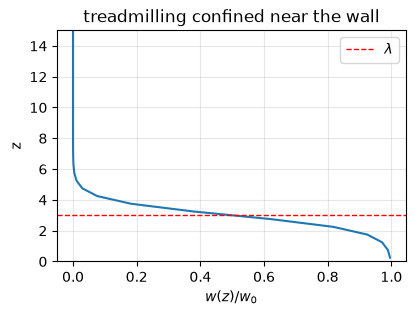

In [5]:
def initialize(R0=R0, eps=eps):
    r = np.sqrt((Y - Ly / 2.0)**2 + Z**2)
    phi = 0.5 * (1.0 - np.tanh((r - R0) / (np.sqrt(2.0) * eps)))
    Py = phi.copy()               # polarization along +y inside the cell
    Pz = np.zeros_like(phi)
    return phi, Py, Pz


def treadmilling_profile(lam=lam, w_tau=w_tau):
    return 0.5 * (1.0 - np.tanh((Z - lam) / w_tau))


fig, ax = plt.subplots(figsize=(4.5, 3))
ax.plot(treadmilling_profile()[0, :], z)
ax.axhline(lam, color="r", ls="--", lw=1, label=r"$\lambda$")
ax.set_xlabel(r"$w(z)/w_0$"); ax.set_ylabel("z"); ax.set_ylim(0, 15)
ax.legend(); ax.grid(alpha=0.3)
ax.set_title("treadmilling confined near the wall")
plt.show()

# 6. Volume conservation

The passive part of the phase-field dynamics uses the chemical potential

$$
\mu \;=\; \frac{\delta F}{\delta\phi} \;=\; -\varepsilon^{2}\nabla^{2}\phi+\phi(\phi-1)(2\phi-1),
$$

the same as in Version 1. Relaxing with $\dot\phi=-M\mu$ (Allen–Cahn) restores a
sharp interface and drives motion by curvature, which is exactly the surface
tension we need — but it does **not** conserve $\int\phi$.

The paper's Cahn–Hilliard form $\nabla\cdot(M\nabla\mu)$ does conserve it, but it
is fourth order, so an explicit scheme would need $dt\sim dx^4$.

We keep second-order cost and get exact conservation by subtracting a spatially
uniform Lagrange multiplier, weighted so that the correction only acts where the
interface is:

$$
\frac{\partial\phi}{\partial t}=-\nabla\cdot(\phi\mathbf u)-M\big[\mu-\beta\,g(\phi)\big],
\qquad g(\phi)=\phi(1-\phi),
\qquad \beta=\frac{\int\mu\,dA}{\int g\,dA}.
$$

Integrating over the domain, the advection term vanishes (flux form, closed
boundaries) and the choice of $\beta$ makes the bracket integrate to zero, so
$\frac{d}{dt}\int\phi\,dA=0$ **exactly**. This is the conservative Allen–Cahn
equation of Rubinstein–Sternberg.

Two things worth noting. First, $g=\phi(1-\phi)$ vanishes in the bulk, so the
correction moves the interface rather than shifting $\phi$ inside the cell.
Second, $\beta$ is a uniform quantity conjugate to volume — it *is* a pressure,
which is why the model can trade a growing protrusion against a retracting rear
without any explicit flow field. The small local density variations this permits
are the ones we agreed to allow.

There is no `clip` anywhere: the double well keeps $\phi$ bounded on its own.

In [6]:
def chemical_potential(phi, eps=eps):
    return -eps**2 * laplacian(phi, 1) + phi * (phi - 1.0) * (2.0 * phi - 1.0)


def volume_conserving_relaxation(phi, eps=eps):
    """-M [ mu - beta g ], with beta fixed so the domain integral vanishes."""
    mu = chemical_potential(phi, eps)
    g = np.clip(phi * (1.0 - phi), 0.0, None)
    beta = mu.sum() / g.sum()
    return -M_phi * (mu - beta * g)

# 7. Polarization

Unchanged in spirit from Version 1, but written with a smooth interior
indicator. Using $\tau=\phi$ and $\phi_{cr}=1/2$ in the paper's free energy, the
bulk coefficient is $-a(\phi-\tfrac12)/\tfrac12 = -2a(\phi-\tfrac12)$, which is
$-a$ deep inside the cell (so $|\mathbf P|\to1$) and $+a$ outside (so
$\mathbf P\to0$), varying smoothly across the interface. Version 1 used a hard
`(phi > 0.5)` step here, which put a discontinuity right at the interface.

$$
\frac{\delta F}{\delta\mathbf P}=-2a\big(\phi-\tfrac12\big)\mathbf P
+a|\mathbf P|^{2}\mathbf P-\kappa\nabla^{2}\mathbf P+\beta_{anch}\nabla\phi
$$

The saturating term $a|\mathbf P|^2\mathbf P$ bounds the magnitude on its own, so
the artificial `|P| < 1.5` clamp of Version 1 is gone.

In [7]:
def polarization_force(phi, Py, Pz):
    p2 = Py**2 + Pz**2
    bulk = -2.0 * a_pol * (phi - 0.5)
    dF_dPy = (bulk * Py + a_pol * p2 * Py
              - kappa * laplacian(Py, 1) + beta_anch * d_dy(phi))
    dF_dPz = (bulk * Pz + a_pol * p2 * Pz
              - kappa * laplacian(Pz, -1) + beta_anch * d_dz(phi, 1))
    return dF_dPy, dF_dPz

# 8. Shape diagnostics

Because the volume is fixed by construction, the informative quantities are all
about **shape** and **motion**:

- **contact length** — extent of $\phi>1/2$ along the wall row. This is our
  analogue of the paper's steady-state size $A_\infty$ in Fig. 1b.
- **maximum height** — how tall the cell body remains. A cell that merely
  flattens into a slab loses height everywhere; a cell that grows a protrusion
  keeps a rounded body.
- **lamella length** — the length of the region whose local height is below
  $2\lambda$, i.e. how far the thin leading layer extends. This is the sharpest
  single indicator that a protrusion exists.
- **centre of mass and crawl speed**. Since $y$ is periodic, $y_{cm}$ is computed
  as a *circular* mean, then unwrapped using the accumulated re-centring shifts.
- **volume error** — should sit at the $10^{-16}$ level. This is the regression
  test for Section 6.

In [8]:
def shape_metrics(phi, lam_thresh):
    inside = phi > 0.5
    height = inside.sum(axis=1) * dz          # local height profile h(y)
    contact_length = inside[:, 0].sum() * dy
    max_height = height.max()
    lamella_length = np.count_nonzero((height > 0) & (height <= lam_thresh)) * dy
    return contact_length, max_height, lamella_length, height


_theta = 2.0 * np.pi * (np.arange(Ny) + 0.5) / Ny

def circular_ycm(phi):
    """Centre of mass in y on a periodic domain, via the circular mean."""
    weight = phi.sum(axis=1)
    ang = np.arctan2((np.sin(_theta) * weight).sum(),
                     (np.cos(_theta) * weight).sum()) % (2.0 * np.pi)
    return ang / (2.0 * np.pi) * Ly

# 9. The Version 2 time loop

Each step does the following.

**A. Drive.** $\;\mathbf d = w(z)\,\mathbf P$.

**B. Velocity.** $\;\mathbf u = (1-\ell_v^2\partial_z^2)^{-1}\mathbf d$ — the
tridiagonal solve of Section 4. This is the only place the missing flow field
enters.

**C. Cell field.** $\;\partial_t\phi=-\nabla\cdot(\phi\mathbf u)-M[\mu-\beta g]$,
conservative advection plus volume-conserving relaxation.

**D. Polarization.** $\;\partial_t\mathbf P=-(\mathbf u\cdot\nabla)\mathbf P
-\Gamma^{-1}\delta F/\delta\mathbf P$.

**E. Bookkeeping.** Sample diagnostics, then re-centre by an integer roll.

Explicit time stepping is stable here because every operator is second order.
The binding constraint is interface diffusion, $dt<dx^2/(4M\varepsilon^2)\approx0.028$;
the advective CFL $dx/w_0$ and the polarization elasticity $dx^2/(4\kappa/\Gamma)$
are both looser. We use $dt=0.01$.

In [9]:
def run_simulation(w0=w0, lv=lv, lam=lam, w_tau=w_tau, eps=eps, R0=R0,
                   t_final=t_final, dt=dt, sample_every=sample_every,
                   snapshot_times=(), state=None, verbose=True):

    screen_y = make_screening_solver(lv, +1)
    screen_z = make_screening_solver(lv, -1)
    w_of_z = w0 * treadmilling_profile(lam, w_tau)

    if state is None:
        phi, Py, Pz = initialize(R0, eps)
    else:
        phi, Py, Pz = (s.copy() for s in state)          # continuation

    V0 = phi.sum()
    shift = 0.0                                          # accumulated re-centring
    n_steps = int(round(t_final / dt))
    snap_steps = {int(round(t / dt)) for t in snapshot_times}

    snapshots = []
    diag = {k: [] for k in
            ["time", "y_cm", "volume", "contact_length", "max_height", "lamella_length"]}

    t_start = time.time()
    for n in range(n_steps):

        # --- A, B: drive, then viscous screening ---
        uy = screen_y(w_of_z * Py)
        uz = screen_z(w_of_z * Pz)

        # --- C: cell field ---
        phi = phi + dt * (-divergence_of_flux(phi, uy, uz)
                          + volume_conserving_relaxation(phi, eps))

        # --- D: polarization ---
        dF_dPy, dF_dPz = polarization_force(phi, Py, Pz)
        Py = Py + dt * (-(uy * d_dy(Py) + uz * d_dz(Py, 1)) - dF_dPy / Gamma)
        Pz = Pz + dt * (-(uy * d_dy(Pz) + uz * d_dz(Pz, -1)) - dF_dPz / Gamma)

        # --- E: bookkeeping ---
        if n in snap_steps:
            snapshots.append((n * dt, shift + circular_ycm(phi),
                              phi.copy(), Py.copy(), Pz.copy()))

        if n % sample_every == 0:
            ycm = circular_ycm(phi)
            Lc, hmax, Llam, _ = shape_metrics(phi, 2.0 * lam)
            diag["time"].append(n * dt)
            diag["y_cm"].append(shift + ycm)             # true, unwrapped
            diag["volume"].append(phi.sum())
            diag["contact_length"].append(Lc)
            diag["max_height"].append(hmax)
            diag["lamella_length"].append(Llam)

            k = int(round((Ly / 2.0 - ycm) / dy))        # integer roll: exact
            if k != 0:
                phi = np.roll(phi, k, axis=0)
                Py = np.roll(Py, k, axis=0)
                Pz = np.roll(Pz, k, axis=0)
                shift -= k * dy

    diag = {k: np.array(v) for k, v in diag.items()}
    diag["speed"] = np.gradient(diag["y_cm"], diag["time"])
    diag["volume_error"] = (phi.sum() - V0) / V0

    if verbose:
        print(f"w0={w0:<5g} lv={lv:<5g}  {time.time()-t_start:5.1f}s   "
              f"relative volume error = {diag['volume_error']:+.2e}")

    return phi, Py, Pz, diag, snapshots

# 10. Visualization

The background is the cell field $\phi$, the green line marks the substrate, and
the white arrows are the actin polarization $\mathbf P$ — which, since
$\mathbf u$ is a screened version of $w(z)\mathbf P$, also shows the direction of
active transport.

In [10]:
def draw_cell(ax, phi, Py, Pz, y_offset=0.0, stride=6, title=None, arrow=False):
    ax.imshow(phi.T, origin="lower", vmin=0.0, vmax=1.0, aspect="equal",
              extent=[-Ly / 2 + y_offset, Ly / 2 + y_offset, 0, Lz])
    ax.quiver(Y[::stride, ::stride] - Ly / 2 + y_offset, Z[::stride, ::stride],
              Py[::stride, ::stride], Pz[::stride, ::stride],
              color="white", scale=30, width=0.002)
    ax.axhline(0.0, color="limegreen", lw=4)             # the no-slip wall
    if arrow:
        ax.annotate("", xy=(28, Lz * 0.72), xytext=(6, Lz * 0.72),
                    arrowprops=dict(width=5, headwidth=13, color="orangered"))
        ax.text(6, Lz * 0.83, "Motion", color="orangered", fontsize=10)
    ax.set_xlim(-46, 46); ax.set_ylim(-2, Lz)
    ax.set_xlabel(r"$y - y_{cm}$"); ax.set_ylabel("z")
    if title:
        ax.set_title(title, fontsize=10)

# 11. Result 1 — a protrusion, and the transition to it

We run two cells that differ **only** in the treadmilling rate $w_0$, exactly as
in Fig. 1a of the paper. Everything else — geometry, volume, $\lambda$, $\ell_v$
— is identical.

In [11]:
snap_times = (0.0, 100.0, 200.0, 300.0, 399.0)

phi_lo, Py_lo, Pz_lo, diag_lo, _ = run_simulation(w0=0.3)
phi_hi, Py_hi, Pz_hi, diag_hi, snaps_hi = run_simulation(w0=2.0,
                                                         snapshot_times=snap_times)

w0=0.3   lv=4       58.2s   relative volume error = -2.97e-16


w0=2     lv=4       57.9s   relative volume error = +0.00e+00


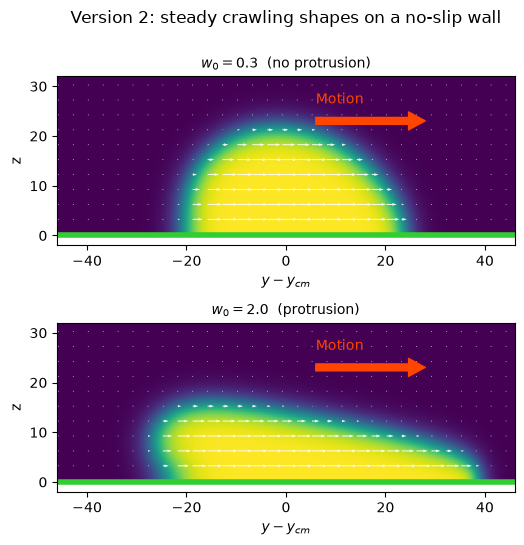

w0 = 0.3:  contact length  44.0   max height  21.5   lamella   1.5   speed 0.050   volume error -3.0e-16
w0 = 2.0:  contact length  63.0   max height  15.5   lamella   6.5   speed 0.432   volume error +0.0e+00


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(11, 5.4))
draw_cell(axes[0], phi_lo, Py_lo, Pz_lo, arrow=True,
          title=r"$w_0 = 0.3$  (no protrusion)")
draw_cell(axes[1], phi_hi, Py_hi, Pz_hi, arrow=True,
          title=r"$w_0 = 2.0$  (protrusion)")
fig.suptitle("Version 2: steady crawling shapes on a no-slip wall", y=1.00)
fig.tight_layout()
plt.show()

for tag, d in [("w0 = 0.3", diag_lo), ("w0 = 2.0", diag_hi)]:
    print(f"{tag}:  contact length {d['contact_length'][-1]:5.1f}   "
          f"max height {d['max_height'][-1]:5.1f}   "
          f"lamella {d['lamella_length'][-1]:5.1f}   "
          f"speed {d['speed'][-4:].mean():.3f}   "
          f"volume error {d['volume_error']:+.1e}")

The slow cell stays essentially a half-disc and creeps forward. The fast cell
keeps a rounded rear but draws its near-wall material out into a thin leading
layer whose tip thickness is set by $\lambda$ — the protrusion. Both conserve
volume to machine precision.

Next, the same fast cell over time, plotted in its own frame so the shapes can
be compared directly. The trajectory is plotted separately.

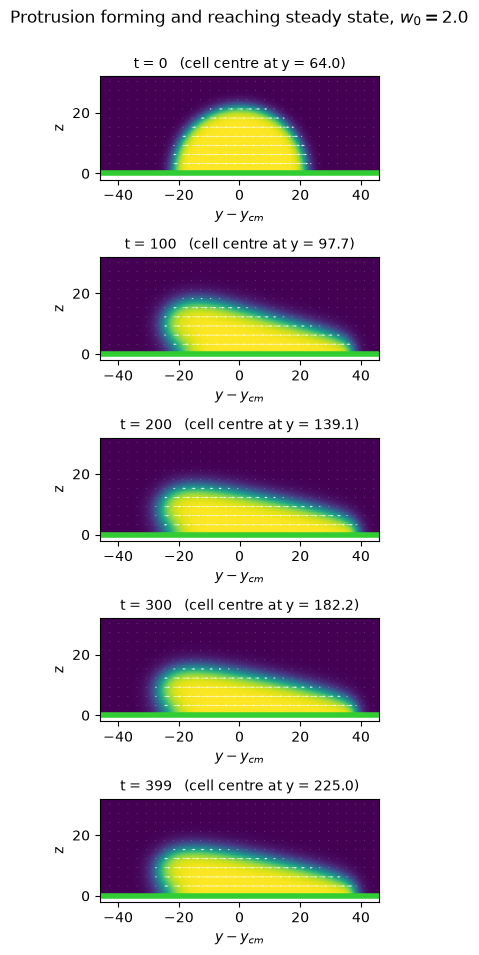

In [13]:
fig, axes = plt.subplots(len(snaps_hi), 1, figsize=(10, 1.9 * len(snaps_hi)))
for ax, (t, ycm, p, py, pz) in zip(axes, snaps_hi):
    draw_cell(ax, p, py, pz, title=f"t = {t:.0f}   (cell centre at y = {ycm:.1f})")
fig.suptitle(r"Protrusion forming and reaching steady state, $w_0 = 2.0$", y=1.00)
fig.tight_layout()
plt.show()

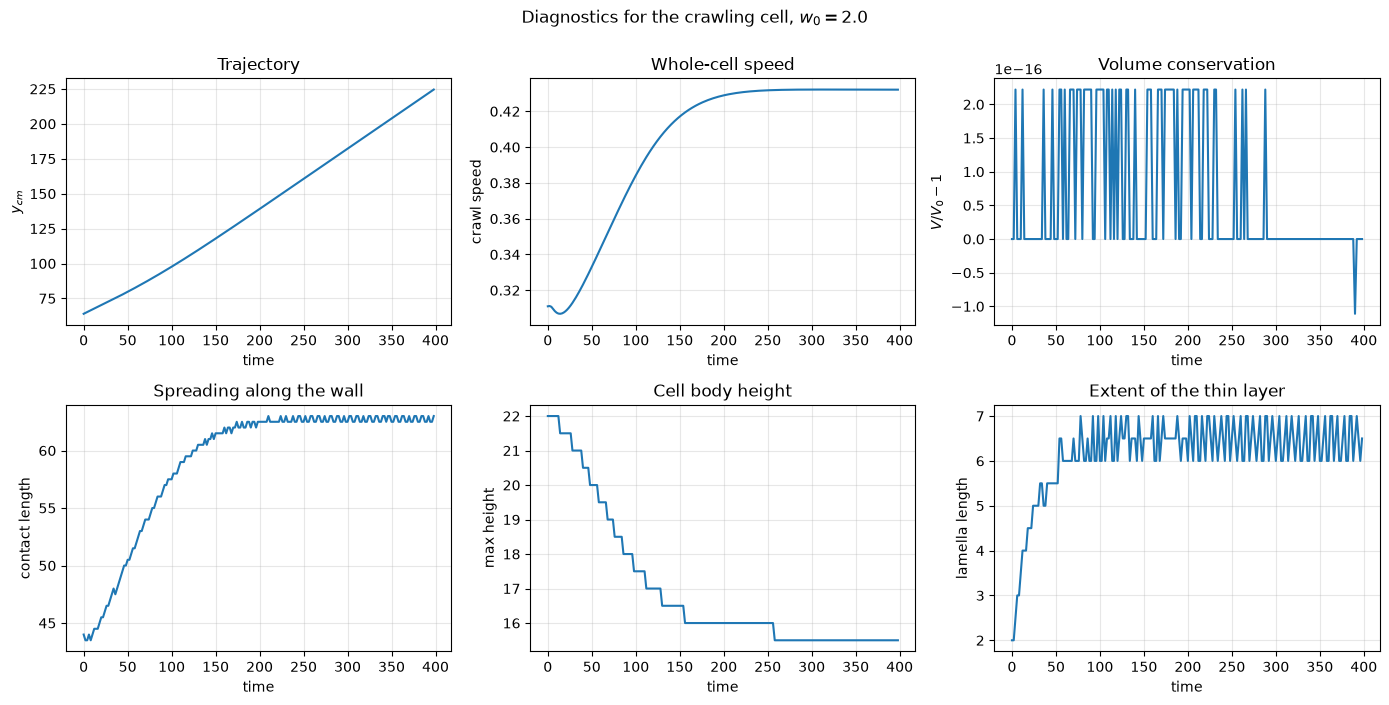

volume drift over the whole run: +0.00e+00  (relative)
Version 1, for comparison, lost about 4.5e-02.


In [14]:
fig, ax = plt.subplots(2, 3, figsize=(14, 7))
t = diag_hi["time"]

ax[0, 0].plot(t, diag_hi["y_cm"])
ax[0, 0].set_ylabel(r"$y_{cm}$"); ax[0, 0].set_title("Trajectory")

ax[0, 1].plot(t, diag_hi["speed"])
ax[0, 1].set_ylabel("crawl speed"); ax[0, 1].set_title("Whole-cell speed")

ax[0, 2].plot(t, diag_hi["volume"] / diag_hi["volume"][0] - 1.0)
ax[0, 2].set_ylabel(r"$V/V_0 - 1$"); ax[0, 2].set_title("Volume conservation")
ax[0, 2].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

ax[1, 0].plot(t, diag_hi["contact_length"])
ax[1, 0].set_ylabel("contact length"); ax[1, 0].set_title("Spreading along the wall")

ax[1, 1].plot(t, diag_hi["max_height"])
ax[1, 1].set_ylabel("max height"); ax[1, 1].set_title("Cell body height")

ax[1, 2].plot(t, diag_hi["lamella_length"])
ax[1, 2].set_ylabel("lamella length"); ax[1, 2].set_title("Extent of the thin layer")

for a in ax.flat:
    a.set_xlabel("time"); a.grid(alpha=0.3)
fig.suptitle(r"Diagnostics for the crawling cell, $w_0 = 2.0$", y=1.00)
fig.tight_layout()
plt.show()

print(f"volume drift over the whole run: {diag_hi['volume_error']:+.2e}  (relative)")
print("Version 1, for comparison, lost about 4.5e-02.")

# 12. Result 2 — the protrusion transition in $w_0$

This is the analogue of Fig. 1b. We sweep the treadmilling rate upward and
record the steady shape at each value.

Each new $w_0$ **continues from the previous steady state** rather than
restarting from a half-disc, so only a short relaxation is needed per point.
Continuing upward also means that, if you later want the paper's hysteresis
check, you only need to add a downward sweep and compare.

In [15]:
w0_list = np.array([0.2, 0.5, 0.8, 1.1, 1.4, 1.7, 2.0, 2.4, 2.8])

state = None
sweep = {"contact_length": [], "max_height": [], "lamella_length": [], "speed": []}
for i, w in enumerate(w0_list):
    phi_s, Py_s, Pz_s, d, _ = run_simulation(
        w0=w, t_final=400.0 if i == 0 else 120.0, state=state)
    state = (phi_s, Py_s, Pz_s)
    sweep["contact_length"].append(d["contact_length"][-1])
    sweep["max_height"].append(d["max_height"][-1])
    sweep["lamella_length"].append(d["lamella_length"][-1])
    sweep["speed"].append(d["speed"][-4:].mean())
sweep = {k: np.array(v) for k, v in sweep.items()}

w0=0.2   lv=4       58.7s   relative volume error = -1.48e-16


w0=0.5   lv=4       17.6s   relative volume error = -1.48e-16


w0=0.8   lv=4       17.8s   relative volume error = +0.00e+00


w0=1.1   lv=4       17.7s   relative volume error = +0.00e+00


w0=1.4   lv=4       17.5s   relative volume error = +0.00e+00


w0=1.7   lv=4       17.7s   relative volume error = +0.00e+00


w0=2     lv=4       17.7s   relative volume error = +0.00e+00


w0=2.4   lv=4       17.5s   relative volume error = -2.97e-16


w0=2.8   lv=4       17.6s   relative volume error = +0.00e+00


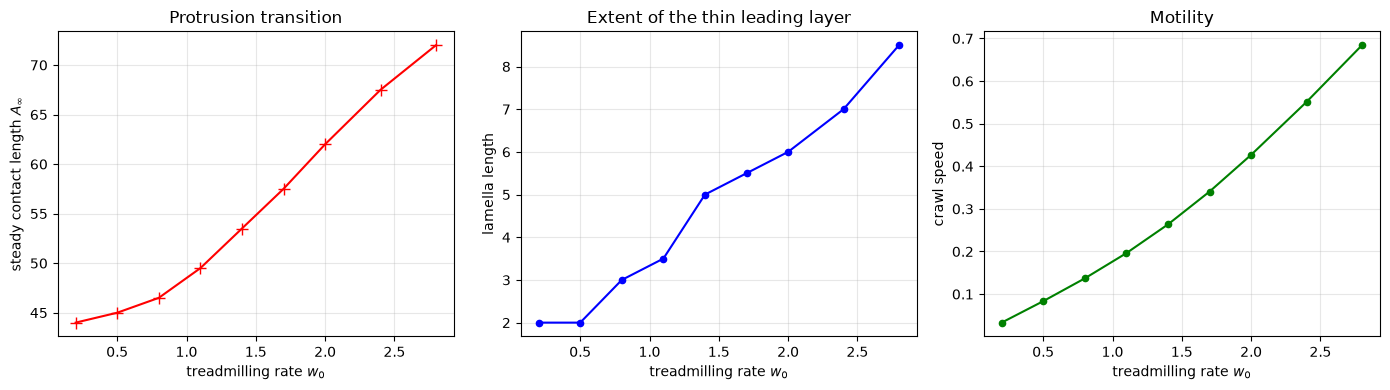

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].plot(w0_list, sweep["contact_length"], "r+-", ms=9)
ax[0].set_ylabel(r"steady contact length $A_\infty$")
ax[0].set_title("Protrusion transition")

ax[1].plot(w0_list, sweep["lamella_length"], "b.-", ms=9)
ax[1].set_ylabel("lamella length")
ax[1].set_title("Extent of the thin leading layer")

ax[2].plot(w0_list, sweep["speed"], "g.-", ms=9)
ax[2].set_ylabel("crawl speed")
ax[2].set_title("Motility")

for a in ax:
    a.set_xlabel(r"treadmilling rate $w_0$"); a.grid(alpha=0.3)
fig.tight_layout()
plt.show()

The contact length is nearly flat while $w_0$ is small, then turns upward around
$w_0\approx1$ and grows steeply — the same qualitative crossover the paper finds
at $w_c$, and for the same reason. A protrusion of thickness $h$ is pulled back
by surface tension at a rate $\sim M\varepsilon^{2}/h$, so a thin layer can only
be sustained once the active push exceeds roughly $M\varepsilon^{2}/\lambda$,
which for these parameters is $\approx0.75$. The lamella length confirms it: it
is essentially the width of the contact line below the knee and grows several
fold above it.

Our crossover is **smooth rather than sharp**. The paper's becomes sharp, and
eventually discontinuous with hysteresis, only once the substrate slip parameter
$s$ is turned on — and $s$ lives in the hydrodynamic boundary condition, which we
do not have.

# 13. Result 3 — adhesion, via the screening length

$\ell_v=\sqrt{\eta/\xi}$ is set by the substrate friction $\xi$, so it is the
closest thing this model has to the paper's slip/adhesion parameter, and it runs
the opposite way: **small $\ell_v$ means strong adhesion.**

w0=2     lv=2       59.5s   relative volume error = +0.00e+00


w0=2     lv=4       29.5s   relative volume error = +0.00e+00


w0=2     lv=8       29.6s   relative volume error = +0.00e+00


w0=2     lv=16      29.5s   relative volume error = -1.48e-16


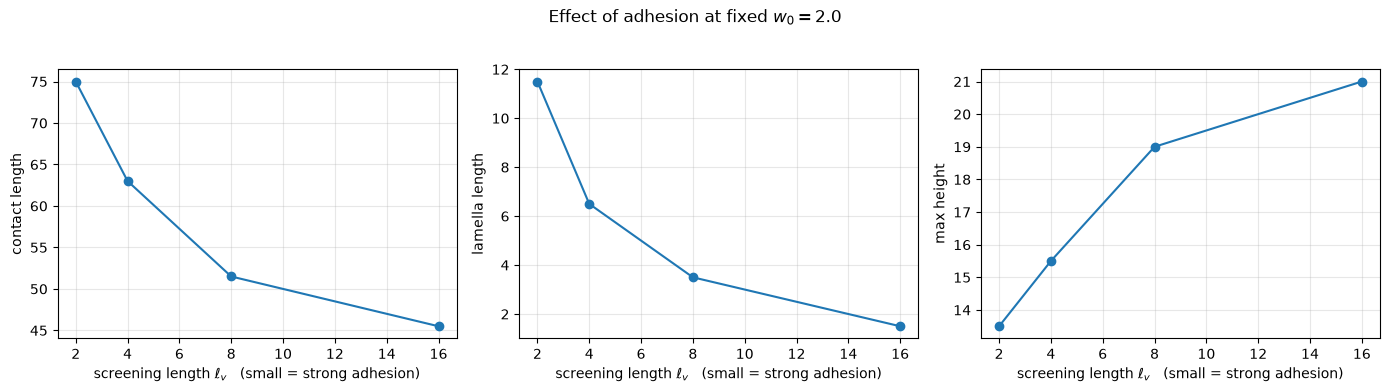

In [17]:
lv_list = np.array([2.0, 4.0, 8.0, 16.0])

state = None
lv_sweep = {"contact_length": [], "max_height": [], "lamella_length": [], "speed": []}
for i, l in enumerate(lv_list):
    phi_s, Py_s, Pz_s, d, _ = run_simulation(
        w0=2.0, lv=l, t_final=400.0 if i == 0 else 200.0, state=state)
    state = (phi_s, Py_s, Pz_s)
    for k in ["contact_length", "max_height", "lamella_length"]:
        lv_sweep[k].append(d[k][-1])
    lv_sweep["speed"].append(d["speed"][-4:].mean())
lv_sweep = {k: np.array(v) for k, v in lv_sweep.items()}

fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
for a, k, lab in zip(ax,
                     ["contact_length", "lamella_length", "max_height"],
                     ["contact length", "lamella length", "max height"]):
    a.plot(lv_list, lv_sweep[k], "o-")
    a.set_xlabel(r"screening length $\ell_v$   (small = strong adhesion)")
    a.set_ylabel(lab); a.grid(alpha=0.3)
fig.suptitle(r"Effect of adhesion at fixed $w_0 = 2.0$", y=1.02)
fig.tight_layout()
plt.show()

Strong adhesion (small $\ell_v$) confines the driving to the substrate, so the
cell shears and spreads into a long thin shape. Weak adhesion (large $\ell_v$)
lets the driving reach the whole cell, which then moves more like a rigid drop
and stays rounded. The paper reports the same direction of effect in Fig. 1c,
where increasing slip removes the protrusion.

# 14. Where Version 2 stands

### What works

- The cell sits on a wall, **grows a thin protrusion at its leading edge**, and
  **crawls steadily** — the qualitative content of Fig. 1a.
- **Volume is conserved to machine precision** ($\sim10^{-16}$ relative), against
  a 4.5% loss in Version 1, and it is conserved *by construction* rather than by
  accuracy. There is no `clip` anywhere.
- There is a **protrusion transition** in $w_0$ with a knee near the value
  predicted by balancing the active push against surface tension at the scale
  $\lambda$.
- Adhesion, entering through $\ell_v$, changes shape and speed in the direction
  the paper reports.
- **No Navier–Stokes solver.** The only concession to hydrodynamics is one
  tridiagonal solve per step.

### The honest limitation

Our protruded cell is a **wedge with a thin leading lamella**, whereas the
paper's Fig. 1a shows a rounded body with a distinctly *stepped* thin tongue.
The reason is specific and worth stating, because it decides what Version 3
should do.

In the paper the whole cell translates at close to $w_0$ and the protrusion is a
thin layer moving slightly *faster* than that. Getting a plateau velocity for
the body plus a separate fast layer requires the internal flow field: an
incompressible flow transports the body coherently while the near-wall layer
slides ahead. Our screening operator instead conserves the depth-integrated
drive, which necessarily makes the near-wall gain come at the expense of the
body, so the velocity profile is monotonic in $z$ and the cell shears.

Note that the *plug* part of the velocity is irrelevant to the shape — adding a
uniform translation is only a Galilean shift. It is the **shape of the shear
profile** $\Delta u(z)$ that decides wedge versus step, and that is what the
Stokes solve would fix.

### Version 3

1. **A Stokes solve** for $\mathbf v$ — pressure projection with viscosity,
   linear and elliptic, no inertia and no Navier–Stokes nonlinearity. This is the
   one ingredient that should convert the wedge into a stepped tongue, and it
   would also let the cell translate at $\sim w_0$ as in the paper.
2. **Contractility** $\zeta$ through the active stress $-\zeta\phi P_\alpha P_\beta$,
   which needs the flow field to act on and which the paper shows is what selects
   between lamellipodium, phagocytic cup and pseudopod.
3. **Anchoring** $\beta_{anch}$, already wired in and currently zero, to splay the
   polarization at the leading edge.
4. **Substrate slip** $s$, to sharpen the transition of Section 12 and look for
   the hysteresis of Fig. 1b.

Only after that does spontaneous polarity, and then the amoeboid oscillation,
become worth adding.